# Modeling
## Gut Microbiome Project · Bar-Ilan University

**Two research questions:**
1. **Dataset 1** — Can we classify food type from its microbiome profile? (10-class + binary fermented)
2. **Dataset 2** — Which specific foods promote a healthy gut microbiome? (gut health score prediction + food ranking)


In [1]:
import warnings
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, r2_score, mean_absolute_error)
from sklearn.linear_model import LogisticRegression
from IPython.display import display

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('once')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

def find_repo_root():
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / 'master_metadata.tsv').exists():
            return p
    raise FileNotFoundError('Cannot find repo root')

REPO_ROOT = find_repo_root()
DIET_ROOT = REPO_ROOT / 'dietstudy_analyses-master'
print(f'Repo root: {REPO_ROOT}')
print(f'XGBoost available: {XGB_AVAILABLE}')

Repo root: C:\Users\winte\microbiome-project_shelano
XGBoost available: False


---
## Part 1 — Dataset 1: Food Microbiome Classification

**Research question:** Can we identify a food's type from its microbial community alone?
If yes, it means the microbiome carries a strong food-type signal — validating our features.

We run two classification tasks:
- **Task A**: 10-class food group classification
- **Task B**: Fermented vs. Non-Fermented (binary)


### Load Dataset 1


In [2]:
d1 = pd.read_csv(REPO_ROOT / 'features_dataset1.csv', index_col=0)
feat_cols_d1 = [c for c in d1.columns if c not in ['food_group','fermented_binary']]

X1 = d1[feat_cols_d1].fillna(0)
y_group    = d1['food_group']
y_ferment  = d1['fermented_binary']

le = LabelEncoder()
y_group_enc = le.fit_transform(y_group)

print(f'Feature matrix : {X1.shape}')
print(f'Class balance  :')
display(y_group.value_counts().rename('count').to_frame())

Feature matrix : (3393, 80)
Class balance  :


,count
food_group,
Cheese,1690
Kefir,672
Other dairy,273
Meat,265
Other food,176
Fish,93
Beverages,77
Fermented vegetables,76
Cocoa / fermented seeds,50


### Task A — 10-Class Food Group Classification


Random Forest — Test Accuracy: 0.925  |  F1-macro: 0.840


5-fold CV F1-macro: 0.848 ± 0.025


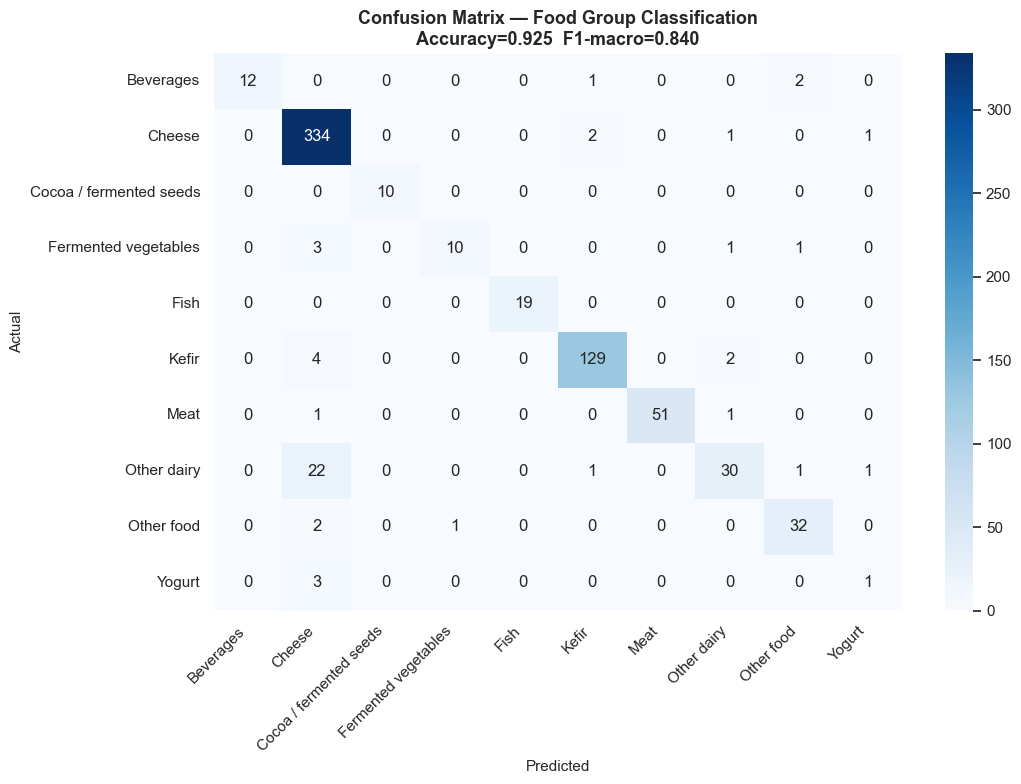

In [3]:
X1_tr, X1_te, yg_tr, yg_te = train_test_split(
    X1, y_group_enc, test_size=0.2, stratify=y_group_enc, random_state=RANDOM_SEED
)

# Random Forest baseline
rf_cls = RandomForestClassifier(
    n_estimators=400, max_depth=None,
    class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
)
rf_cls.fit(X1_tr, yg_tr)
yg_pred = rf_cls.predict(X1_te)

acc_rf  = accuracy_score(yg_te, yg_pred)
f1_rf   = f1_score(yg_te, yg_pred, average='macro')

print(f'Random Forest — Test Accuracy: {acc_rf:.3f}  |  F1-macro: {f1_rf:.3f}')

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(rf_cls, X1, y_group_enc, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'5-fold CV F1-macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# XGBoost if available
if XGB_AVAILABLE:
    xgb_cls = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_SEED, n_jobs=-1
    )
    xgb_cls.fit(X1_tr, yg_tr)
    yg_xgb = xgb_cls.predict(X1_te)
    acc_xgb = accuracy_score(yg_te, yg_xgb)
    f1_xgb  = f1_score(yg_te, yg_xgb, average='macro')
    print(f'XGBoost         — Test Accuracy: {acc_xgb:.3f}  |  F1-macro: {f1_xgb:.3f}')

# Confusion matrix
cm = confusion_matrix(yg_te, yg_pred)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual',    fontsize=11)
ax.set_title(
    f'Confusion Matrix — Food Group Classification\n'
    f'Accuracy={acc_rf:.3f}  F1-macro={f1_rf:.3f}',
    weight='bold', fontsize=13
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task B — Fermented vs. Non-Fermented (Binary)


In [4]:
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    X1, y_ferment, test_size=0.2, stratify=y_ferment, random_state=RANDOM_SEED
)
rf_bin = RandomForestClassifier(
    n_estimators=400, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
)
rf_bin.fit(Xf_tr, yf_tr)
yf_pred = rf_bin.predict(Xf_te)
acc_f   = accuracy_score(yf_te, yf_pred)
f1_f    = f1_score(yf_te, yf_pred, average='macro', zero_division=0)
print(f'Fermented vs Non-Fermented — Accuracy: {acc_f:.3f}  F1-macro: {f1_f:.3f}')
print(classification_report(yf_te, yf_pred, zero_division=0))

# Compare model results
summary = pd.DataFrame({
    'Task':     ['Food Group (10-class)', 'Fermented vs Non-Fermented'],
    'Model':    ['Random Forest', 'Random Forest'],
    'Accuracy': [f'{acc_rf:.3f}', f'{acc_f:.3f}'],
    'F1-macro': [f'{f1_rf:.3f}', f'{f1_f:.3f}'],
})
print('\n--- Dataset 1 Results Summary ---')
display(summary)

Fermented vs Non-Fermented — Accuracy: 1.000  F1-macro: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       679

    accuracy                           1.00       679
   macro avg       1.00      1.00      1.00       679
weighted avg       1.00      1.00      1.00       679


--- Dataset 1 Results Summary ---


,Task,Model,Accuracy,F1-macro
0,Food Group (10-class),Random Forest,0.925,0.840
1,Fermented vs Non-Fermented,Random Forest,1.000,1.000


---
## Part 2 — Dataset 2: Which Foods Are Best for Your Gut?

**Research question:** Given what a person ate yesterday, can we predict
how their gut microbiome will change today — and which specific foods drive better gut health?

### What is a 'Gut Health Score'?

We define a composite score combining:
- **Beneficial bacteria** (Bifidobacterium, Faecalibacterium, Akkermansia, Lactobacillus) — higher CLR = better
- **Diversity** (Shannon entropy change) — more diverse = better

Each component is Z-score standardized before combining so no single taxon dominates.

> Score > 0 → **Good gut day** · Score < 0 → **Challenging gut day**


### Step 1 · Load Outcomes and Define Gut Health Score


Transitions with gut health score: 350
Good gut days  : 177 (50.6%)
Bad  gut days  : 173


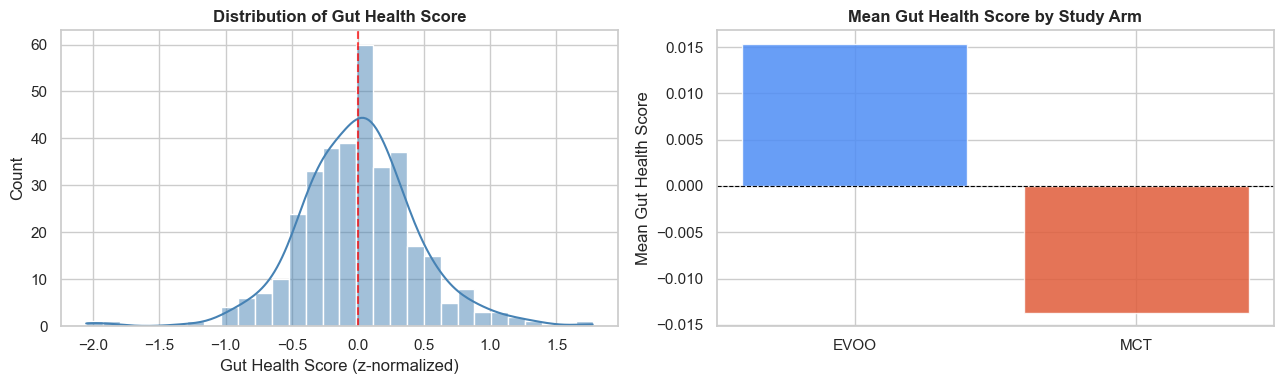

In [5]:
d2 = pd.read_csv(REPO_ROOT / 'features_dataset2.csv')

BENEFICIAL = ['Bifidobacterium', 'Faecalibacterium', 'Akkermansia', 'Lactobacillus']
dclr_ben   = [f'dCLR_{t}' for t in BENEFICIAL]

# Z-score each component across all transitions
score_parts = []
for col in dclr_ben + ['Delta_EntTaxa']:
    if col in d2.columns:
        z = (d2[col] - d2[col].mean()) / (d2[col].std() + 1e-9)
        score_parts.append(z)

score_df = pd.concat(score_parts, axis=1)
d2['GutHealthScore'] = score_df.mean(axis=1)
d2['GoodGutDay']     = (d2['GutHealthScore'] > 0).astype(int)

print(f'Transitions with gut health score: {d2["GutHealthScore"].notna().sum()}')
print(f'Good gut days  : {d2["GoodGutDay"].sum()} ({100*d2["GoodGutDay"].mean():.1f}%)')
print(f'Bad  gut days  : {(~d2["GoodGutDay"].astype(bool)).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(d2['GutHealthScore'].dropna(), bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Distribution of Gut Health Score', weight='bold')
axes[0].set_xlabel('Gut Health Score (z-normalized)')

arm_scores = d2.groupby('Supplement_MCT')['GutHealthScore'].mean()
axes[1].bar(['EVOO','MCT'], arm_scores.values,
            color=['#4e8df5','#e05c3a'], alpha=0.85)
axes[1].set_title('Mean Gut Health Score by Study Arm', weight='bold')
axes[1].set_ylabel('Mean Gut Health Score')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### Step 2 · Build Specific-Food Feature Matrix

We load the raw food diaries and build a matrix where:
- **Rows** = transitions (indexed by PrevSampleID = yesterday)
- **Columns** = specific food items
- **Values** = grams consumed

Only foods appearing in **≥ 15 transitions** are kept (77 foods).


In [6]:
FOOD_DIR = DIET_ROOT / 'data' / 'procrustes' / 'data_username_1day'
MIN_OBS  = 15

logs = []
for fp in sorted(FOOD_DIR.glob('*_food.txt')):
    tmp = pd.read_csv(fp, sep='\t')
    sid_cols = [c for c in tmp.columns if c not in ['#FoodID','taxonomy']]
    tmp_long = tmp.melt(id_vars=['#FoodID','taxonomy'], value_vars=sid_cols,
                         var_name='PrevSampleID', value_name='Grams')
    tmp_long['Grams'] = pd.to_numeric(tmp_long['Grams'], errors='coerce')
    tmp_long = tmp_long.loc[tmp_long['Grams'] > 0]
    tmp_long['Food_Name'] = tmp_long['taxonomy'].apply(
        lambda t: str(t).split(';')[-1].strip() if pd.notna(t) else 'Unknown')
    logs.append(tmp_long[['PrevSampleID','Food_Name','Grams']])

diet_long = pd.concat(logs, ignore_index=True)
diet_long['PrevSampleID'] = diet_long['PrevSampleID'].astype(str)

# Filter to PrevSampleIDs in our transitions
valid_prev = set(d2['PrevSampleID'].astype(str))
diet_long  = diet_long.loc[diet_long['PrevSampleID'].isin(valid_prev)]

# Filter to foods with enough observations
food_obs = diet_long.groupby('Food_Name')['PrevSampleID'].nunique()
common_foods = food_obs[food_obs >= MIN_OBS].index
diet_filtered = diet_long.loc[diet_long['Food_Name'].isin(common_foods)]

# Pivot: PrevSampleID x Food_Name -> Grams
food_matrix = (
    diet_filtered.groupby(['PrevSampleID','Food_Name'])['Grams']
    .sum().unstack(fill_value=0)
)
food_matrix.columns.name = None

# Join with outcomes
d2_str = d2.copy()
d2_str['PrevSampleID'] = d2_str['PrevSampleID'].astype(str)
model_df = d2_str.join(food_matrix, on='PrevSampleID', how='inner')

print(f'Specific foods after MIN_OBS={MIN_OBS} filter: {len(common_foods)}')
print(f'Transitions with food data: {len(model_df)}')
print(f'Food feature matrix shape: {food_matrix.shape}')

Specific foods after MIN_OBS=15 filter: 77
Transitions with food data: 349
Food feature matrix shape: (349, 77)


### Step 3 · Train Gut Health Prediction Model

We train a **Random Forest Regressor** to predict the Gut Health Score from specific food consumption.
The model learns which combinations of foods are associated with better or worse microbiome changes.

**Feature importance** directly answers: *which specific food matters most for gut health?*


Regression  — R²: -0.111  |  MAE: 0.355


Classification — Accuracy: 0.477  |  F1-macro: 0.477


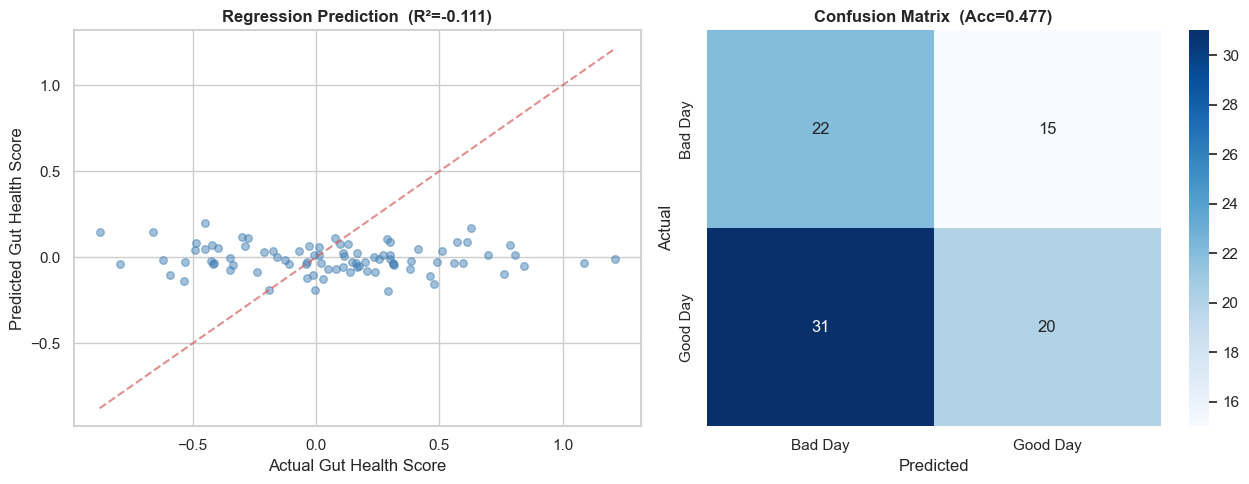

In [7]:
food_cols = list(common_foods)
X_food    = model_df[food_cols].fillna(0)
y_score   = model_df['GutHealthScore'].fillna(0)
y_good    = model_df['GoodGutDay'].fillna(0).astype(int)

# Add nutrition features as controls
nutr_cols = [c for c in model_df.columns if c.startswith('nutr_')]
X_full    = pd.concat([X_food, model_df[nutr_cols + ['Supplement_MCT','StudyDayNo_norm']].fillna(0)], axis=1)

# Train/test split
X_tr, X_te, ys_tr, ys_te, yg_tr2, yg_te2 = train_test_split(
    X_full, y_score, y_good, test_size=0.25, random_state=RANDOM_SEED
)

# Regression: predict score
rf_reg = RandomForestRegressor(
    n_estimators=500, max_depth=6,
    min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1
)
rf_reg.fit(X_tr, ys_tr)
ys_pred = rf_reg.predict(X_te)
r2_val  = r2_score(ys_te, ys_pred)
mae_val = mean_absolute_error(ys_te, ys_pred)
print(f'Regression  — R²: {r2_val:.3f}  |  MAE: {mae_val:.3f}')

# Classification: predict good/bad day
rf_cls2 = RandomForestClassifier(
    n_estimators=500, max_depth=6,
    class_weight='balanced', min_samples_leaf=3,
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_cls2.fit(X_tr, yg_tr2)
yg_pred2 = rf_cls2.predict(X_te)
acc_g    = accuracy_score(yg_te2, yg_pred2)
f1_g     = f1_score(yg_te2, yg_pred2, average='macro')
print(f'Classification — Accuracy: {acc_g:.3f}  |  F1-macro: {f1_g:.3f}')

# Scatter: predicted vs actual score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(ys_te, ys_pred, alpha=0.5, s=30, color='steelblue')
lims = [min(ys_te.min(), ys_pred.min()), max(ys_te.max(), ys_pred.max())]
axes[0].plot(lims, lims, 'r--', alpha=0.7)
axes[0].set_xlabel('Actual Gut Health Score')
axes[0].set_ylabel('Predicted Gut Health Score')
axes[0].set_title(f'Regression Prediction  (R²={r2_val:.3f})', weight='bold')

cm2 = confusion_matrix(yg_te2, yg_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad Day','Good Day'],
            yticklabels=['Bad Day','Good Day'], ax=axes[1])
axes[1].set_title(f'Confusion Matrix  (Acc={acc_g:.3f})', weight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Step 4 · Food Health Ranking — Which Foods Are Best?

We combine two signals to rank each food:
1. **RF Feature Importance** — how much the model relies on this food (controls for confounders)
2. **Mean Gut Health Score** on days when the food was eaten vs. not eaten

The final bar chart directly answers: *eat more of X, avoid Y.*


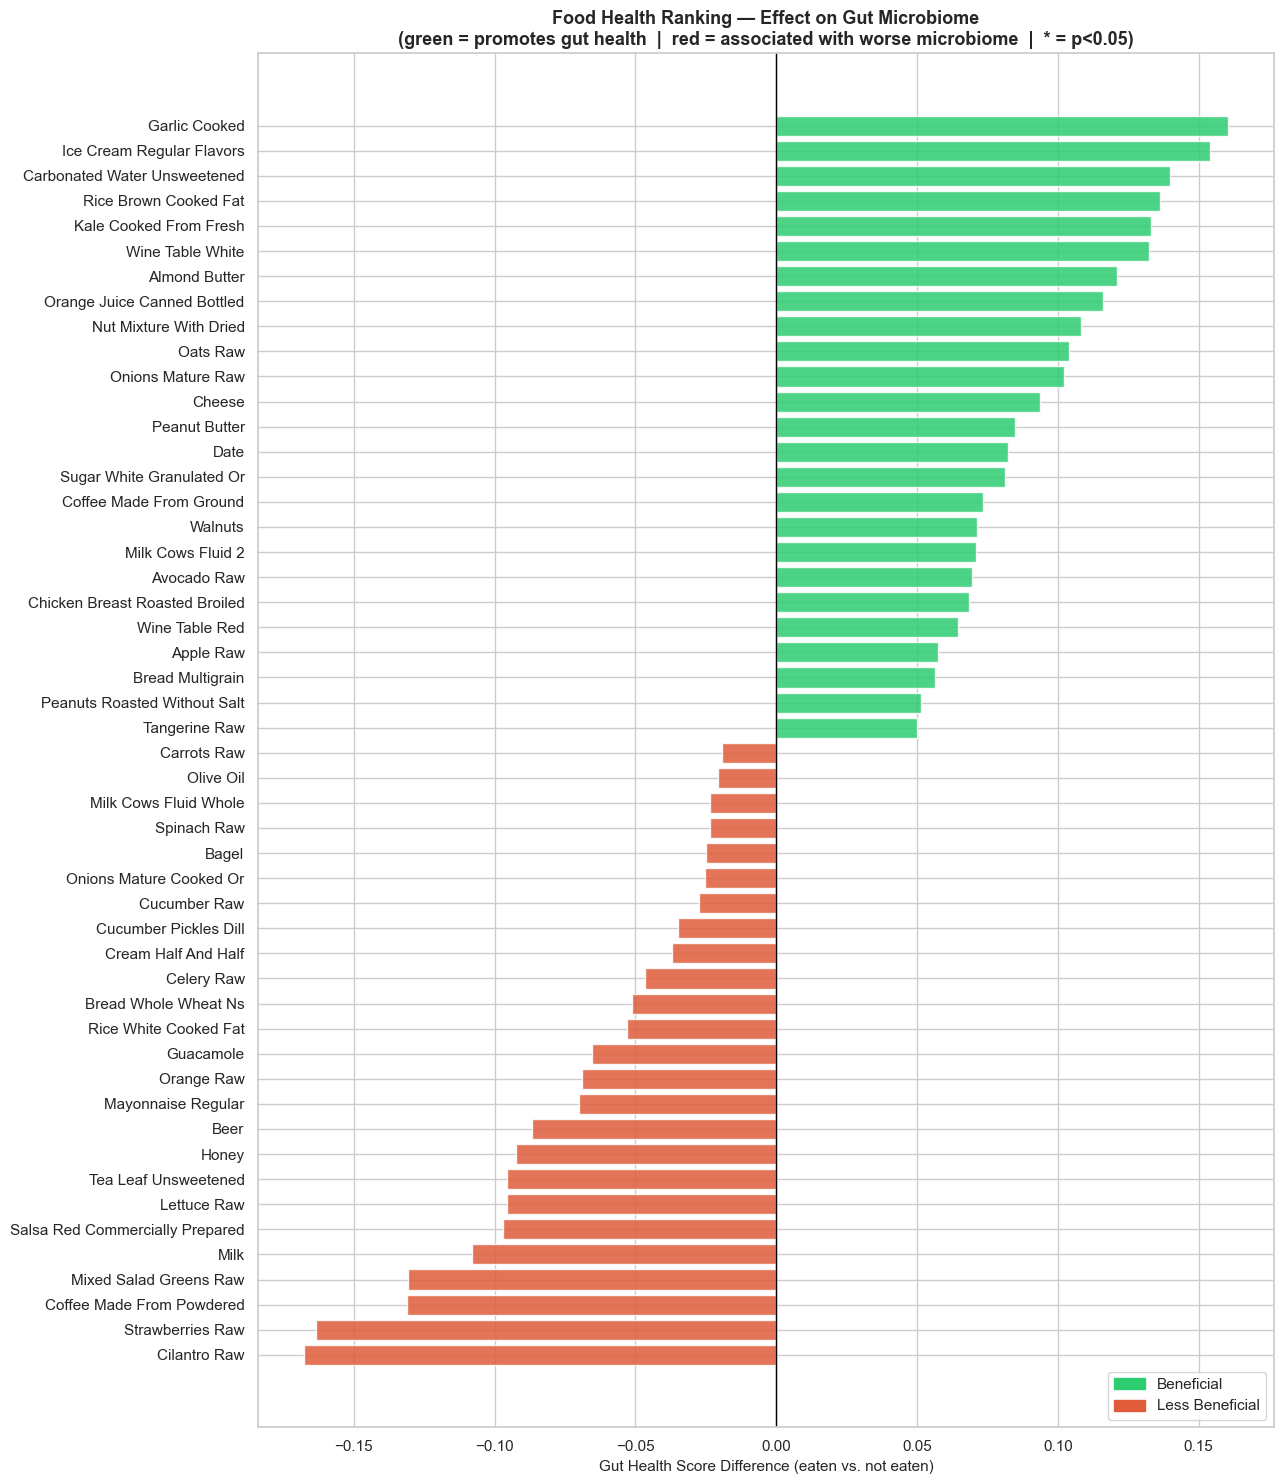


Top 10 BEST foods for gut health:


,label,score_diff,n_transitions,p_value
Garlic_cooked,Garlic Cooked,0.1603,20.0,0.1648
Ice_cream_regular_flavors_other_than_chocolate,Ice Cream Regular Flavors,0.1540,16.0,0.1092
Carbonated_water_unsweetened,Carbonated Water Unsweetened,0.1399,22.0,0.1421
Rice_brown_cooked_fat_not_added_in_cooking,Rice Brown Cooked Fat,0.1363,15.0,0.1282
Kale_cooked_from_fresh_fat_not_added_in_cooking,Kale Cooked From Fresh,0.1331,15.0,0.2155
Wine_table_white,Wine Table White,0.1322,15.0,0.1976
Almond_butter,Almond Butter,0.1212,18.0,0.2118
Orange_juice_canned_bottled_or_in_a_carton,Orange Juice Canned Bottled,0.1159,20.0,0.0786
Nut_mixture_with_dried_fruit_and_seeds,Nut Mixture With Dried,0.1084,16.0,0.3672
Oats_raw,Oats Raw,0.1041,15.0,0.3107



Top 10 WORST foods for gut health:


,label,score_diff,n_transitions,p_value
Beer,Beer,-0.0868,57.0,0.4195
Honey,Honey,-0.0924,30.0,0.1721
Tea_leaf_unsweetened,Tea Leaf Unsweetened,-0.0955,30.0,0.3406
Lettuce_raw,Lettuce Raw,-0.0957,37.0,0.1604
Salsa_red_commercially_prepared,Salsa Red Commercially Prepared,-0.0972,58.0,0.1013
Milk_NFS,Milk,-0.1080,15.0,0.2817
Mixed_salad_greens_raw,Mixed Salad Greens Raw,-0.1307,32.0,0.3395
Coffee_made_from_powdered_instant_regular,Coffee Made From Powdered,-0.1311,15.0,0.1566
Strawberries_raw,Strawberries Raw,-0.1635,17.0,0.5666
Cilantro_raw,Cilantro Raw,-0.1676,18.0,0.1036


In [8]:
# Feature importances from regression model (food features only)
imp_series = pd.Series(rf_reg.feature_importances_, index=X_full.columns)
food_imp   = imp_series[food_cols].sort_values(ascending=False)

# Mean gut health score: eaten vs not eaten
eaten_scores = {}
for food in food_cols:
    mask_eaten    = model_df[food] > 0
    score_eaten   = model_df.loc[mask_eaten,  'GutHealthScore'].mean()
    score_not     = model_df.loc[~mask_eaten, 'GutHealthScore'].mean()
    n_eaten       = int(mask_eaten.sum())
    # Mann-Whitney U test
    try:
        _, pval = stats.mannwhitneyu(
            model_df.loc[mask_eaten,  'GutHealthScore'].dropna(),
            model_df.loc[~mask_eaten, 'GutHealthScore'].dropna(),
            alternative='two-sided'
        )
    except Exception:
        pval = 1.0
    eaten_scores[food] = {
        'score_when_eaten':  score_eaten,
        'score_when_not':    score_not,
        'score_diff':        score_eaten - score_not,
        'n_transitions':     n_eaten,
        'p_value':           pval,
        'rf_importance':     food_imp.get(food, 0),
    }

ranking_df = pd.DataFrame(eaten_scores).T
ranking_df = ranking_df.sort_values('score_diff', ascending=False)

def clean_name(n):
    parts = n.replace('_NFS','').split('_')
    return ' '.join(parts[:4]).title()

ranking_df['label'] = [clean_name(f) for f in ranking_df.index]
ranking_df['significant'] = ranking_df['p_value'] < 0.05

TOP_SHOW = 25
top_foods    = ranking_df.head(TOP_SHOW)
bottom_foods = ranking_df.tail(TOP_SHOW)
plot_df      = pd.concat([top_foods, bottom_foods]).drop_duplicates()
plot_df      = plot_df.sort_values('score_diff')

colors = ['#e05c3a' if v < 0 else '#2ecc71' for v in plot_df['score_diff']]
fig, ax = plt.subplots(figsize=(13, max(10, 0.3*len(plot_df))))
bars = ax.barh(plot_df['label'], plot_df['score_diff'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    if row['significant']:
        x = bar.get_width()
        ax.text(x + 0.005 if x >= 0 else x - 0.005,
                bar.get_y() + bar.get_height()/2,
                '*', va='center', ha='left' if x >= 0 else 'right',
                fontsize=14, color='black', weight='bold')
ax.set_xlabel('Gut Health Score Difference (eaten vs. not eaten)', fontsize=11)
ax.set_title(
    'Food Health Ranking — Effect on Gut Microbiome\n'
    '(green = promotes gut health  |  red = associated with worse microbiome  |  * = p<0.05)',
    weight='bold', fontsize=13
)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2ecc71', label='Beneficial'),
    Patch(color='#e05c3a', label='Less Beneficial'),
], loc='lower right')
plt.tight_layout()
plt.show()

print('\nTop 10 BEST foods for gut health:')
display(ranking_df[['label','score_diff','n_transitions','p_value']].head(10).round(4))
print('\nTop 10 WORST foods for gut health:')
display(ranking_df[['label','score_diff','n_transitions','p_value']].tail(10).round(4))

### Step 5 · Per-Bacteria Heatmap — Which Food Boosts Which Bacterium?

For each food × bacterium pair, we compute the **mean DeltaCLR** on days when that food was eaten.
This reveals *which specific bacterium benefits from each food* — a mechanistic view.


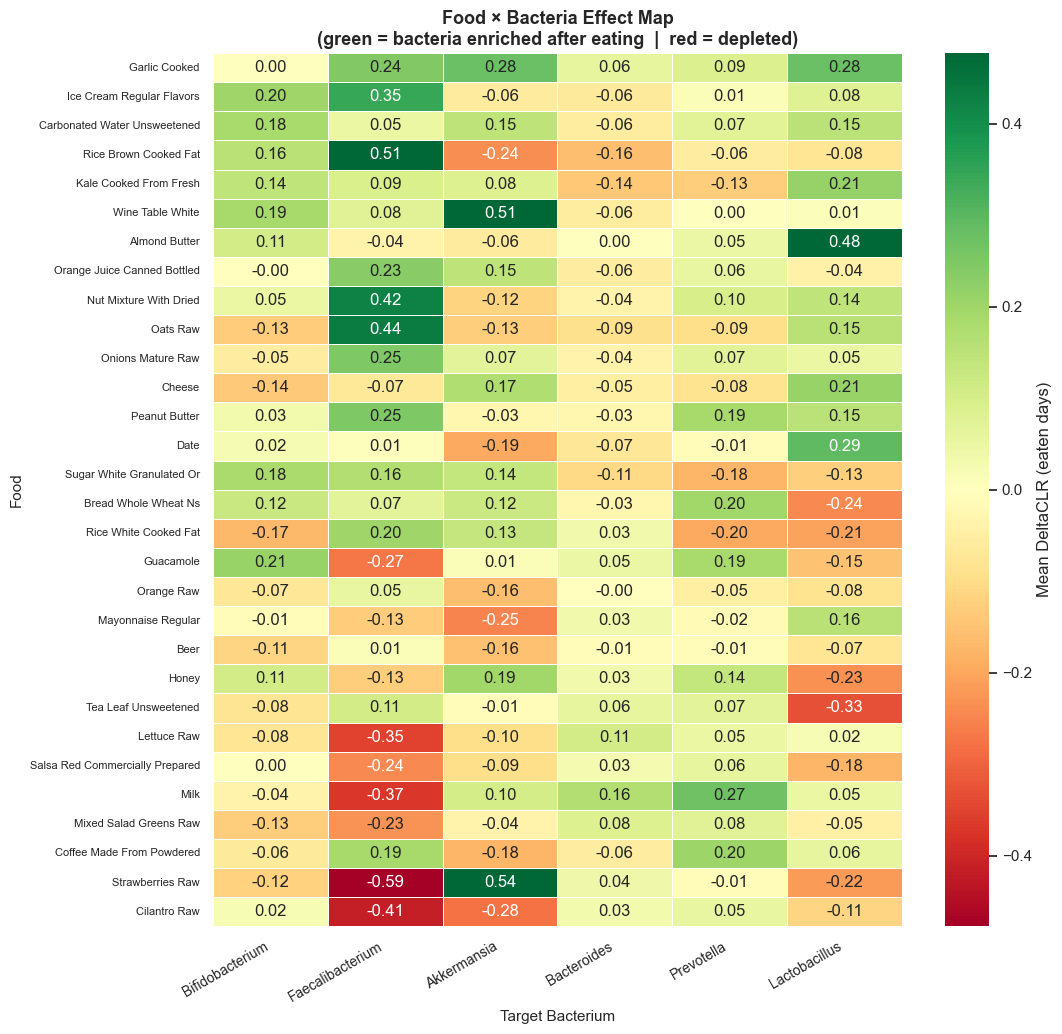

In [9]:
ALL_TAXA = ['Bifidobacterium','Faecalibacterium','Akkermansia',
            'Bacteroides','Prevotella','Lactobacillus']
dclr_all = [f'dCLR_{t}' for t in ALL_TAXA]

TOP_HEATMAP = 30
top_foods_hm = ranking_df.head(TOP_HEATMAP // 2).index.tolist() + \
               ranking_df.tail(TOP_HEATMAP // 2).index.tolist()
top_foods_hm = list(dict.fromkeys(top_foods_hm))  # preserve order, deduplicate

heatmap_data = []
for food in top_foods_hm:
    row_vals = {}
    mask = model_df[food] > 0
    for col, taxon in zip(dclr_all, ALL_TAXA):
        if col in model_df.columns and mask.sum() > 0:
            row_vals[taxon] = model_df.loc[mask, col].mean()
        else:
            row_vals[taxon] = np.nan
    heatmap_data.append(row_vals)

hm_df = pd.DataFrame(heatmap_data, index=top_foods_hm)
hm_df.index = [clean_name(f) for f in hm_df.index]

fig, ax = plt.subplots(figsize=(11, max(8, 0.35*len(hm_df))))
vmax = float(hm_df.abs().quantile(0.95).max())
sns.heatmap(
    hm_df, cmap='RdYlGn', center=0, vmin=-vmax, vmax=vmax,
    annot=True, fmt='.2f', linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Mean DeltaCLR (eaten days)'}
)
ax.set_title(
    'Food × Bacteria Effect Map\n(green = bacteria enriched after eating  |  red = depleted)',
    weight='bold', fontsize=13
)
ax.set_xlabel('Target Bacterium', fontsize=11)
ax.set_ylabel('Food', fontsize=11)
plt.yticks(fontsize=8)
plt.xticks(fontsize=10, rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Step 6 · Practical Recommendations Summary

Based on our model, here are actionable dietary insights from the data.


In [10]:
best_5  = ranking_df.head(5)
worst_5 = ranking_df.tail(5)

print('=' * 60)
print('PRACTICAL GUT HEALTH RECOMMENDATIONS')
print('Based on 350 person-day transitions across 32 participants')
print('=' * 60)
print()
print('\u2705  EAT MORE — Associated with healthier microbiome:')
for _, row in best_5.iterrows():
    sig = ' (*)' if row['p_value'] < 0.05 else ''
    print(f"   {row['label']:<35} score diff: {row['score_diff']:+.3f}{sig}")

print()
print('\u26a0\ufe0f  EAT LESS — Associated with worse microbiome:')
for _, row in worst_5.iterrows():
    sig = ' (*)' if row['p_value'] < 0.05 else ''
    print(f"   {row['label']:<35} score diff: {row['score_diff']:+.3f}{sig}")

print()
print('(*) = statistically significant (Mann-Whitney U, p < 0.05)')
print()
print('IMPORTANT CAVEATS:')
print('  - Observational study: associations, not causal effects')
print('  - N=32 participants; individual variation is high')
print('  - Multiple comparisons: FDR correction recommended for publication')
print('  - Results may be confounded by other foods eaten the same day')

# Final summary table
final_table = ranking_df[['label','score_diff','n_transitions','p_value','rf_importance']].copy()
final_table.columns = ['Food','Score Diff','N Transitions','p-value','RF Importance']
final_table = final_table.round(4)
final_table.to_csv(REPO_ROOT / 'food_health_ranking.csv', index=False)
print('\nFull ranking saved to food_health_ranking.csv')
display(final_table.head(20))

PRACTICAL GUT HEALTH RECOMMENDATIONS
Based on 350 person-day transitions across 32 participants

✅  EAT MORE — Associated with healthier microbiome:
   Garlic Cooked                       score diff: +0.160
   Ice Cream Regular Flavors           score diff: +0.154
   Carbonated Water Unsweetened        score diff: +0.140
   Rice Brown Cooked Fat               score diff: +0.136
   Kale Cooked From Fresh              score diff: +0.133

⚠️  EAT LESS — Associated with worse microbiome:
   Milk                                score diff: -0.108
   Mixed Salad Greens Raw              score diff: -0.131
   Coffee Made From Powdered           score diff: -0.131
   Strawberries Raw                    score diff: -0.164
   Cilantro Raw                        score diff: -0.168

(*) = statistically significant (Mann-Whitney U, p < 0.05)

IMPORTANT CAVEATS:
  - Observational study: associations, not causal effects
  - N=32 participants; individual variation is high
  - Multiple comparisons: FDR c

,Food,Score Diff,N Transitions,p-value,RF Importance
Garlic_cooked,Garlic Cooked,0.1603,20.0,0.1648,0.0187
Ice_cream_regular_flavors_other_than_chocolate,Ice Cream Regular Flavors,0.1540,16.0,0.1092,0.0004
Carbonated_water_unsweetened,Carbonated Water Unsweetened,0.1399,22.0,0.1421,0.0017
Rice_brown_cooked_fat_not_added_in_cooking,Rice Brown Cooked Fat,0.1363,15.0,0.1282,0.0000
Kale_cooked_from_fresh_fat_not_added_in_cooking,Kale Cooked From Fresh,0.1331,15.0,0.2155,0.0021
Wine_table_white,Wine Table White,0.1322,15.0,0.1976,0.0026
Almond_butter,Almond Butter,0.1212,18.0,0.2118,0.0021
Orange_juice_canned_bottled_or_in_a_carton,Orange Juice Canned Bottled,0.1159,20.0,0.0786,0.0008
Nut_mixture_with_dried_fruit_and_seeds,Nut Mixture With Dried,0.1084,16.0,0.3672,0.0018
Oats_raw,Oats Raw,0.1041,15.0,0.3107,0.0007
